
# Image registration based on manually predefined points

In [233]:
import xmltodict
import numpy as np
import scipy.ndimage as ndi
from collections import OrderedDict
import matplotlib.pyplot as plt
import imageio
from skimage import transform as trf

In [4]:
template_path = "/Users/celefthe/mesoscopy_testing/preprocessed/sub-MM234_exp-109hrb21d_ses-20220311_test-dataset-2mins_landmarks.points"

sample_path = "/Users/celefthe/mesoscopy_testing/preprocessed/sub-MM237_exp-109hrb21d_ses-20220311_test-dataset-2mins_landmarks.points"

In [5]:
with open(template_path, "r") as fp:
    template = xmltodict.parse(fp.read())

with open(sample_path, "r") as fp:
    sample = xmltodict.parse(fp.read())

In [6]:
template

OrderedDict([('namedpointset',
              OrderedDict([('@version', '1.0'),
                           ('pointworld',
                            [OrderedDict([('@set', 'true'),
                                          ('@name', 'bregma'),
                                          ('@x', '67.0'),
                                          ('@y', '56.0'),
                                          ('@z', '0.0')]),
                             OrderedDict([('@set', 'true'),
                                          ('@name', 'cFP'),
                                          ('@x', '66.0'),
                                          ('@y', '17.0'),
                                          ('@z', '0.0')]),
                             OrderedDict([('@set', 'true'),
                                          ('@name', 'lFP'),
                                          ('@x', '48.0'),
                                          ('@y', '16.0'),
                                          ('@z', '

In [10]:
{point['@name']: (point['@x'], point['@y']) for point in template["namedpointset"]["pointworld"]}

{'bregma': ('67.0', '56.0'),
 'cFP': ('66.0', '17.0'),
 'lFP': ('48.0', '16.0'),
 'rFP': ('84.0', '16.0'),
 'lPB': ('31.0', '32.0'),
 'rPB': ('103.0', '33.0'),
 'lpRSP': ('62.0', '114.0'),
 'rpRSP': ('75.0', '114.0'),
 'aIPB': ('67.0', '107.0')}

In [19]:
with open(template_path, "r") as fp:
    template = xmltodict.parse(fp.read())
    template = OrderedDict({
        point['@name']:
            (point['@x'], point['@y']) for point in template["namedpointset"]["pointworld"]
    })

with open(sample_path, "r") as fp:
    sample = xmltodict.parse(fp.read())
    sample = OrderedDict({
        point['@name']:
            (point['@x'], point['@y']) for point in sample["namedpointset"]["pointworld"]
    })

In [20]:
template

OrderedDict([('bregma', ('67.0', '56.0')),
             ('cFP', ('66.0', '17.0')),
             ('lFP', ('48.0', '16.0')),
             ('rFP', ('84.0', '16.0')),
             ('lPB', ('31.0', '32.0')),
             ('rPB', ('103.0', '33.0')),
             ('lpRSP', ('62.0', '114.0')),
             ('rpRSP', ('75.0', '114.0')),
             ('aIPB', ('67.0', '107.0'))])

In [21]:
sample

OrderedDict([('bregma', ('68.0', '61.0')),
             ('cFP', ('68.0', '23.0')),
             ('lFP', ('43.0', '20.0')),
             ('rFP', ('91.0', '20.0')),
             ('lPB', ('31.0', '36.0')),
             ('rPB', ('104.0', '36.0')),
             ('lpRSP', ('62.0', '120.0')),
             ('rpRSP', ('73.0', '120.0')),
             ('aIPB', ('69.0', '114.0'))])

In [31]:
np.array(list(sample.values()))

array([['68.0', '61.0'],
       ['68.0', '23.0'],
       ['43.0', '20.0'],
       ['91.0', '20.0'],
       ['31.0', '36.0'],
       ['104.0', '36.0'],
       ['62.0', '120.0'],
       ['73.0', '120.0'],
       ['69.0', '114.0']], dtype='<U5')

In [214]:
template_landmarks = np.array(list(template.values()), dtype=np.float32)
sample_landmarks = np.array(list(sample.values()), dtype=np.float32)

(142.0, 0.0)

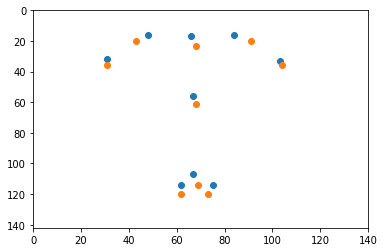

In [259]:
plt.scatter(template_landmarks[:, 0], template_landmarks[:, 1])
plt.scatter(sample_landmarks[:, 0], sample_landmarks[:, 1])
plt.xlim(0,140)
plt.ylim(142, 0)

In [234]:
tform = trf.estimate_transform('affine', template_landmarks, sample_landmarks)

(142.0, 0.0)

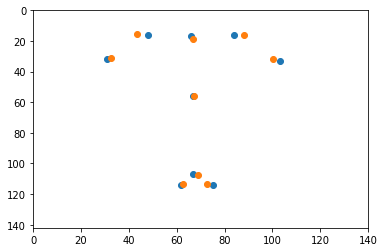

In [235]:
tform.inverse(template_landmarks)

plt.scatter(template_landmarks[:, 0], template_landmarks[:, 1])
plt.scatter(tform.inverse(sample_landmarks)[:, 0], tform.inverse(sample_landmarks)[:, 1])
plt.xlim(0,140)
plt.ylim(142, 0)

In [236]:
template_img = imageio.imread('/Users/celefthe/mesoscopy_testing/preprocessed/qa/sub-MM234_exp-109hrb21d_ses-20220311_test-dataset-2mins_qa_gcamp_maxip.png', as_gray=True)

sample_img = imageio.imread('/Users/celefthe/mesoscopy_testing/preprocessed/qa/sub-MM237_exp-109hrb21d_ses-20220311_test-dataset-2mins_qa_gcamp_maxip.png', as_gray=True)

In [273]:
#sample_img_t = ndi.affine_transform(sample_img, matrix=tform)
sample_img_t = transform.warp(sample_img, tform, order=3)

In [274]:
tform.params

array([[ 1.07811239, -0.01462788, -3.74607674],
       [-0.01199653,  1.02343898,  4.48858042],
       [ 0.        ,  0.        ,  1.        ]])

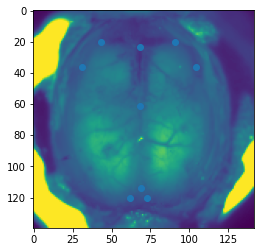

In [275]:
plt.imshow(sample_img)
plt.scatter(sample_landmarks[:, 0], sample_landmarks[:, 1])

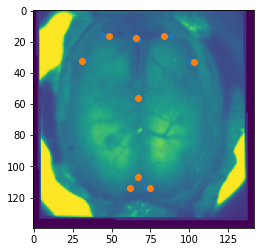

In [276]:
plt.imshow(sample_img_t)
plt.scatter(tform.inverse(sample_landmarks)[:, 0], tform.inverse(sample_landmarks)[:, 1])
plt.scatter(template_landmarks[:, 0], template_landmarks[:, 1])

(array([[140.,   0.,   0., ...,   0.,   0.,   0.],
        [140.,   0.,   0., ...,   0.,   0.,   0.],
        [111.,  29.,   0., ...,   0.,   0.,   0.],
        ...,
        [140.,   0.,   0., ...,   0.,   0.,   0.],
        [140.,   0.,   0., ...,   0.,   0.,   0.],
        [140.,   0.,   0., ...,   0.,   0.,   0.]]),
 array([  0.      ,  21.534801,  43.069603,  64.6044  ,  86.139206,
        107.674   , 129.2088  , 150.7436  , 172.27841 , 193.8132  ,
        215.348   ], dtype=float32),
 <a list of 142 BarContainer objects>)

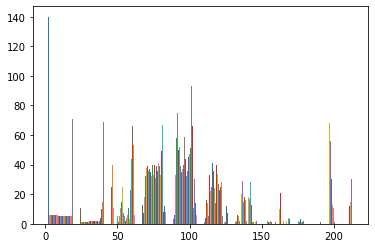

In [271]:
plt.hist(sample_img_t)

(array([[23., 16.,  8., ...,  2.,  1., 71.],
        [28., 19.,  8., ...,  0.,  1., 72.],
        [33., 16.,  5., ...,  1.,  3., 70.],
        ...,
        [24., 53.,  9., ...,  2.,  0., 30.],
        [27., 52., 11., ...,  3.,  0., 30.],
        [30., 51., 11., ...,  1.,  1., 29.]]),
 array([ 30.495   ,  48.9803  ,  67.4656  ,  85.950905, 104.4362  ,
        122.9215  , 141.4068  , 159.8921  , 178.37741 , 196.8627  ,
        215.348   ], dtype=float32),
 <a list of 142 BarContainer objects>)

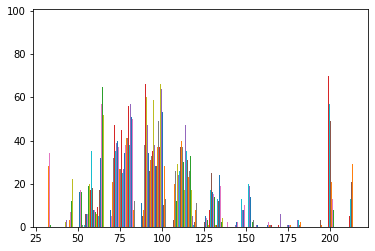

In [272]:
plt.hist(sample_img)

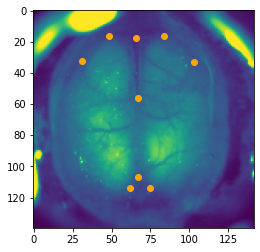

In [266]:
plt.imshow(template_img)
plt.scatter(template_landmarks[:, 0], template_landmarks[:, 1], color='orange')

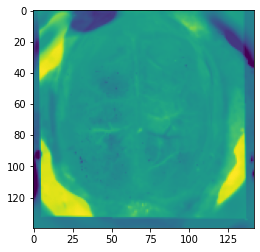

In [251]:
plt.imshow(sample_img_t - template_img)

(array([[3., 5., 3., ..., 5., 4., 5.],
        [5., 3., 3., ..., 5., 4., 4.],
        [5., 3., 4., ..., 4., 4., 3.],
        ...,
        [0., 8., 0., ..., 1., 2., 8.],
        [0., 7., 3., ..., 2., 1., 8.],
        [0., 3., 5., ..., 2., 2., 8.]]),
 array([-162.76141 , -128.28116 ,  -93.80089 ,  -59.32063 ,  -24.840368,
           9.639893,   44.120155,   78.60042 ,  113.08067 ,  147.56094 ,
         182.0412  ], dtype=float32),
 <a list of 142 BarContainer objects>)

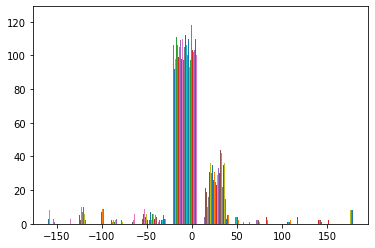

In [112]:
plt.hist(ndi.affine_transform(sample_img, transform[1]) - sample_img)